# Network Intrusion Detection & Security Analytics

This project analyzes network traffic from the UNSW-NB15 cybersecurity dataset to identify patterns associated with normal activity and malicious attacks.

The goal is to explore network behavior, analyze attack categories and protocols, and build a machine learning model capable of distinguishing normal traffic from potential intrusions.

In [1]:
import pandas as pd

train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)

train_df.head()

Training set: (175341, 45)
Testing set: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 2. Data Inspection

The training dataset was inspected to understand its structure, feature types, missing values, duplicates, and target variables before performing security analysis and machine learning.

In [2]:
print("Rows and columns:", train_df.shape)

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

Rows and columns: (175341, 45)

Column names:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Missing values:
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit  

In [3]:
print("Total missing values:", train_df.isnull().sum().sum())

print("\nData types:")
print(train_df.dtypes)

print("\nTarget label counts:")
print(train_df["label"].value_counts())

print("\nAttack categories:")
print(train_df["attack_cat"].value_counts())

Total missing values: 0

Data types:
id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst

## 3. Normal vs. Malicious Network Traffic

The target label was analyzed to determine the distribution of normal and malicious network connections in the training dataset.

In [4]:
label_counts = train_df["label"].value_counts().sort_index()

print("Normal traffic:", label_counts.get(0, 0))
print("Attack traffic:", label_counts.get(1, 0))

print("\nTraffic distribution (%):")
print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Normal traffic: 56000
Attack traffic: 119341

Traffic distribution (%):
label
0    31.94
1    68.06
Name: proportion, dtype: float64


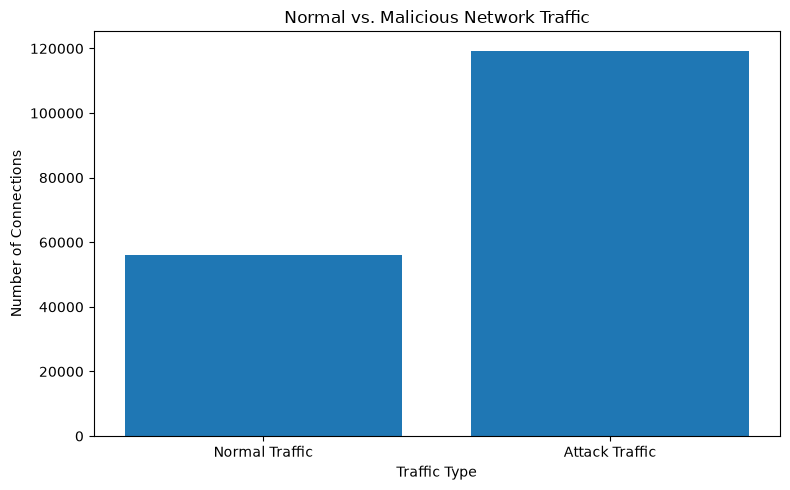

In [5]:
import matplotlib.pyplot as plt

traffic_counts = train_df["label"].value_counts().sort_index()

traffic_names = ["Normal Traffic", "Attack Traffic"]

plt.figure(figsize=(8, 5))
plt.bar(traffic_names, traffic_counts.values)

plt.title("Normal vs. Malicious Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Connections")

plt.tight_layout()
plt.show()

## 4. Attack Category Analysis

Malicious traffic was analyzed by attack category to determine which types of cyberattacks appear most frequently in the training dataset.

In [6]:
attack_counts = (
    train_df.loc[train_df["label"] == 1, "attack_cat"]
    .value_counts()
)

attack_counts

attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

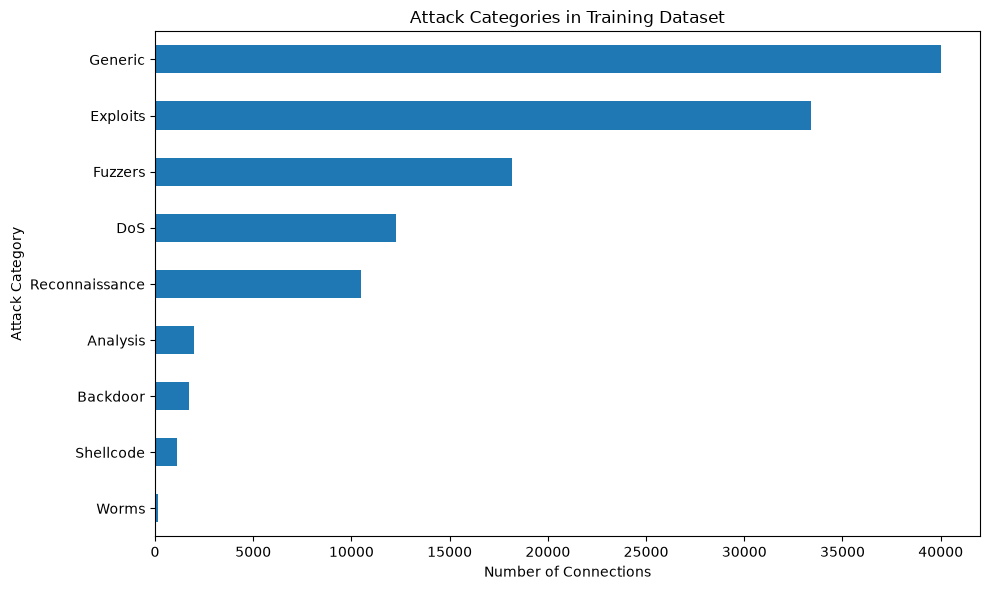

In [7]:
plt.figure(figsize=(10, 6))

attack_counts.sort_values().plot(kind="barh")

plt.title("Attack Categories in Training Dataset")
plt.xlabel("Number of Connections")
plt.ylabel("Attack Category")

plt.tight_layout()
plt.show()

## 5. Protocol Analysis

Network protocols were analyzed to identify which protocols appear most frequently and how malicious traffic is distributed across them.

In [8]:
protocol_counts = train_df["proto"].value_counts().head(10)

print("Top 10 protocols:")
print(protocol_counts)

Top 10 protocols:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201
Name: count, dtype: int64


In [9]:
attack_protocols = (
    train_df[train_df["label"] == 1]["proto"]
    .value_counts()
    .head(10)
)

print("Top protocols used in attack traffic:")
print(attack_protocols)

Top protocols used in attack traffic:
proto
udp       49361
tcp       40825
unas      12084
ospf       2531
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201
mobile      201
Name: count, dtype: int64


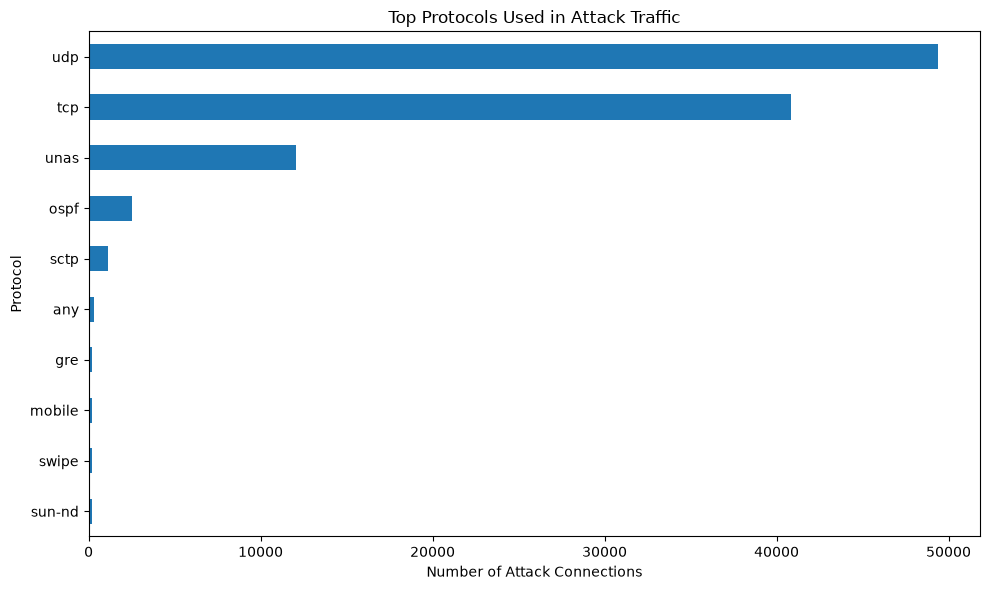

In [10]:
plt.figure(figsize=(10, 6))

attack_protocols.sort_values().plot(kind="barh")

plt.title("Top Protocols Used in Attack Traffic")
plt.xlabel("Number of Attack Connections")
plt.ylabel("Protocol")

plt.tight_layout()
plt.show()

## 6. Service Analysis

Network services were analyzed to identify which application-level services appear most frequently and which services are most associated with malicious traffic.

In [11]:
service_counts = train_df["service"].value_counts().head(10)

print("Top 10 services:")
print(service_counts)

Top 10 services:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64


In [12]:
attack_services = (
    train_df[train_df["label"] == 1]["service"]
    .value_counts()
    .head(10)
)

print("Top services used in attack traffic:")
print(attack_services)

Top services used in attack traffic:
service
-           57656
dns         39801
http        13376
smtp         3479
ftp          2210
ftp-data     1443
pop3         1101
dhcp           94
snmp           79
ssl            56
Name: count, dtype: int64


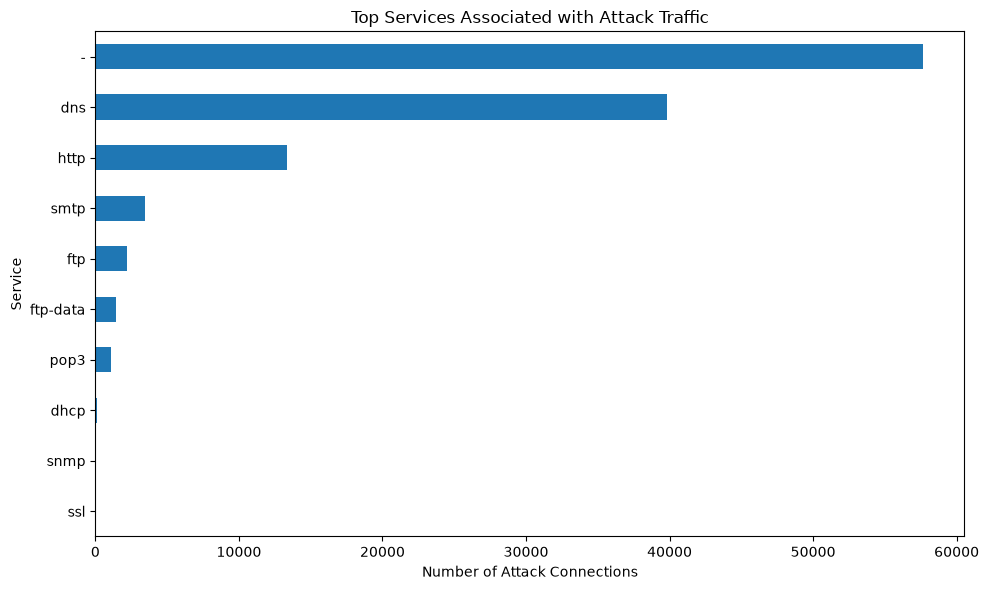

In [13]:
plt.figure(figsize=(10, 6))

attack_services.sort_values().plot(kind="barh")

plt.title("Top Services Associated with Attack Traffic")
plt.xlabel("Number of Attack Connections")
plt.ylabel("Service")

plt.tight_layout()
plt.show()

## 7. Machine Learning Intrusion Detection

A binary classification model was developed to distinguish normal network traffic from malicious traffic.

The official UNSW-NB15 training and testing datasets were used separately so that model performance could be evaluated on unseen network connections.

The `label` variable is the prediction target:

- **0 = Normal traffic**
- **1 = Attack traffic**

In [14]:
# Separate features and target variables

X_train = train_df.drop(
    columns=["label", "attack_cat", "id"]
)

y_train = train_df["label"]

X_test = test_df.drop(
    columns=["label", "attack_cat", "id"]
)

y_test = test_df["label"]

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:")
print(len(numerical_features))

Training features: (175341, 42)
Testing features: (82332, 42)

Categorical features:
['proto', 'service', 'state']

Number of numerical features:
39


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [18]:
from sklearn.linear_model import LogisticRegression

# Create machine learning pipeline
intrusion_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                random_state=42
            )
        )
    ]
)

print("Intrusion detection model created successfully.")

Intrusion detection model created successfully.


In [19]:
print("Training intrusion detection model...")

intrusion_model.fit(X_train, y_train)

print("Model training complete.")

Training intrusion detection model...
Model training complete.


C:\Users\axell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predict unseen testing data
y_pred = intrusion_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8069
Precision: 0.7508
Recall:    0.9718
F1 Score:  0.8471


### Model Evaluation

The trained intrusion-detection model was evaluated on the official UNSW-NB15 testing dataset.

The model achieved high recall, indicating that it successfully detected most malicious network connections. A confusion matrix was used to examine false positives and false negatives in greater detail.

Confusion Matrix:
[[22375 14625]
 [ 1277 44055]]


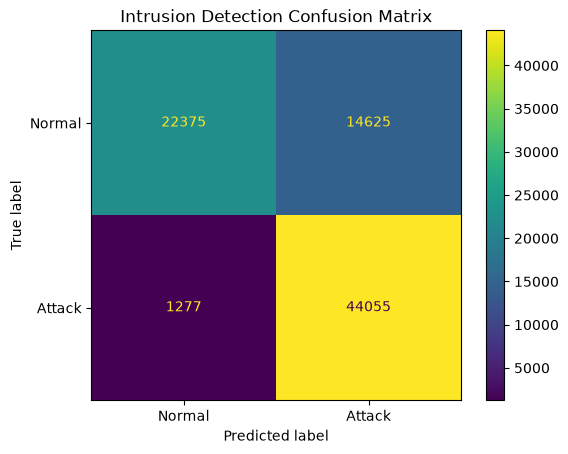

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()
plt.title("Intrusion Detection Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

              precision    recall  f1-score   support

      Normal       0.95      0.60      0.74     37000
      Attack       0.75      0.97      0.85     45332

    accuracy                           0.81     82332
   macro avg       0.85      0.79      0.79     82332
weighted avg       0.84      0.81      0.80     82332



## 8. Key Findings and Security Insights

The analysis identified several important patterns in the UNSW-NB15 network traffic dataset:

- Attack traffic represented approximately 68% of the training dataset.
- Generic and Exploit attacks were the most frequently observed attack categories.
- UDP and TCP accounted for the largest amount of malicious network traffic.
- DNS and HTTP were among the most frequently observed services associated with attacks.
- The logistic regression intrusion-detection model achieved approximately 81% overall accuracy.
- The model achieved approximately 97% recall for malicious traffic, meaning it detected the vast majority of attacks in the testing dataset.
- The model produced more false positives than false negatives, indicating that it favors attack detection sensitivity over minimizing false alarms.

### Business and Security Interpretation

For an intrusion-detection system, high attack recall can be valuable because missed attacks may create significant security risk. However, excessive false positives can increase the workload for security analysts.

Future improvements could focus on reducing false positives while maintaining high attack detection rates through feature engineering, threshold optimization, or alternative machine-learning models.